# Chapter 7: Surfaces

**Source orientation:** Armstrong, *Basic Topology*, Chapter 7, printed pp. 149-172; PDF pp. 159-181. The source span was used for structure, terminology, and theorem flow only. The prose, diagrams, examples, and checks below are original course material.

## Chapter Goal

Classify closed connected surfaces by turning the theorem into computations a reader can inspect: polygon edge schemas, orientability constraints, Euler characteristic ledgers, surgery moves, connected sums, and small triangulated models.

A closed surface in this chapter is compact, connected, has no boundary, and is locally planar. The classification theorem says that every such surface belongs to exactly one of three families:

- the sphere `S^2`,
- an orientable surface `H(p)`, made by adding `p` handles to the sphere,
- a nonorientable surface `M(q)`, made by attaching `q` crosscaps or Mobius bands to the sphere.

The working data are not coordinates. They are gluing instructions, cell counts, and consistency constraints.

## Computational Translation Guide

| Chapter idea | Computational model in this notebook | Invariant or check |
| --- | --- | --- |
| Standard surfaces | Records for `S^2`, `H(p)`, and `M(q)` | `chi(H(p)) = 2 - 2p`, `chi(M(q)) = 2 - q` |
| Surface symbols | Labeled polygon edge words | each label appears twice; opposite signs detect orientable schemas |
| Orientability | Triangle orientation constraints on explicit finite triangulations | constraint propagation succeeds or finds a contradiction |
| Euler characteristic bound | Maximal primal tree plus dual graph scaffold | `chi(K) = chi(T) + chi(Gamma)` and `chi(T)=1` |
| Surgery | Replacing a thickened nonseparating curve by disk caps | `chi` increases by `2` for a cylinder, by `1` for a Mobius band |
| Mixed handles and crosscaps | Normalization rule | if at least one crosscap is present, `m` handles and `n` crosscaps become `M(2m+n)` |

## Visual Storyboard

1. Build a classification ledger where orientability and Euler characteristic separate the standard families.
2. Draw surface-symbol polygons for orientable and nonorientable edge words.
3. Test orientability on small triangulated sphere, torus, and Klein bottle models.
4. Use the primal-tree/dual-graph scaffold to make the Euler characteristic proof strategy visible.
5. Run a surgery and connected-sum lab that tracks how handles and crosscaps change `chi`.

In [1]:
from __future__ import annotations

from collections import Counter, defaultdict, deque
from pathlib import Path
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Polygon
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go


def find_book_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
            return candidate
    raise RuntimeError("Could not find Basic-Topology book root")


BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib, save_plotly_html

UNIT = "chapter-07"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
HTML_DIR = ARTIFACT_ROOT / "html"
for folder in [FIG_DIR, CHECK_DIR, TABLE_DIR, HTML_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

ARTIFACTS: list[Path] = []
CHECK_PATHS: list[Path] = []

PALETTE = {
    "ink": "#1f2937",
    "blue": "#2563eb",
    "teal": "#0f766e",
    "green": "#16a34a",
    "gold": "#d97706",
    "red": "#dc2626",
    "purple": "#7c3aed",
    "gray": "#64748b",
    "light": "#eef2ff",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#cbd5e1",
    "axes.labelcolor": PALETTE["ink"],
    "xtick.color": PALETTE["ink"],
    "ytick.color": PALETTE["ink"],
    "font.size": 10,
})

BOOK_ROOT.relative_to(BOOK_ROOT.parent)

WindowsPath('Basic-Topology')

In [2]:
storyboard = {
    "chapter_goal": "Classify closed surfaces through symbols, orientability tests, Euler characteristic, and surgery.",
    "source_span_read": {
        "source_pdf": "Basic-Topology/armstrong-basic-topology.pdf",
        "printed_pages": "149-172",
        "pdf_pages": "159-181",
        "source_use": "orientation only; no copied prose, exercises, screenshots, page crops, or figures",
    },
    "concept_inventory": [
        "closed surface and standard families S^2, H(p), M(q)",
        "handle attachment versus crosscap/Mobius attachment",
        "triangulable/combinatorial surface assumptions",
        "compatible triangle orientations and one-sided obstruction",
        "Euler characteristic, maximal trees, and dual graphs",
        "surgery along nonseparating curves",
        "surface symbols and polygon edge words",
        "connected sum normalization and genus ledger",
    ],
    "library_routing_table": [
        {"concept": "polygon edge schemas", "representation": "labeled 2D polygon diagrams", "library": "Matplotlib", "why": "static labeled arrows expose the quotient instruction directly"},
        {"concept": "orientability", "representation": "finite triangulation constraint propagation", "library": "NetworkX + Python data structures", "why": "the obstruction is a graph consistency problem"},
        {"concept": "Euler proof scaffold", "representation": "dependency graph and dual graph ledger", "library": "NetworkX + Matplotlib", "why": "the proof depends on tree and dual graph relationships"},
        {"concept": "surgery lab", "representation": "interactive chi trajectories", "library": "Plotly", "why": "stage-by-stage Euler changes are easier to compare interactively"},
        {"concept": "classification ledgers", "representation": "tables and exact formulas", "library": "Pandas", "why": "surface families are discrete records with checkable formulas"},
    ],
    "visual_sequence": [
        "surface-classification-ledger.png",
        "surface-symbol-edge-schemas.png",
        "triangulated-surface-orientability.png",
        "euler-dual-tree-proof-scaffold.png",
        "surgery-connected-sum-ledger.png",
        "surgery-euler-lab.html",
    ],
    "computational_checks": [
        "Euler formulas for orientable and nonorientable standard surfaces",
        "surface-symbol labels occur exactly twice",
        "triangulation edges have exactly two incident triangles",
        "orientability succeeds for sphere and torus, fails for Klein bottle",
        "dual-tree identity chi(K) = 1 + chi(Gamma)",
        "surgery raises chi by the expected amount",
        "all expected artifacts exist and are nonempty",
    ],
}

storyboard_path = save_json(storyboard, UNIT, "checks", "visual-storyboard.json")
ARTIFACTS.append(storyboard_path)
CHECK_PATHS.append(storyboard_path)
storyboard_path.relative_to(BOOK_ROOT)

WindowsPath('artifacts/chapter-07/checks/visual-storyboard.json')

## Classification Ledger

The classification theorem is easiest to use as a ledger. The orientable line is indexed by the number of handles. The nonorientable line is indexed by the number of crosscaps. Euler characteristic does not by itself detect orientability, since the torus `H(1)` and Klein bottle `M(2)` both have `chi = 0`; orientability is a separate bit of data.

The mixed case is the key bookkeeping move: once a crosscap is present, a handle can be traded for two crosscaps. Thus a sphere with `m` handles and `n > 0` crosscaps belongs to `M(2m+n)`.

This ledger also explains why the chapter uses several kinds of evidence at once. A polygon word tells us how the surface is assembled, a triangulation lets us count cells and propagate orientations, and surgery gives a way to move toward the sphere without pretending the drawing is rigid. The invariant work is split on purpose: `chi` records how many handles or crosscaps must be present, while the orientability test decides which family the same `chi` value belongs to.

In [3]:
def chi_orientable(p: int) -> int:
    if p < 0:
        raise ValueError("genus must be nonnegative")
    return 2 - 2 * p


def chi_nonorientable(q: int) -> int:
    if q <= 0:
        raise ValueError("nonorientable genus must be positive")
    return 2 - q


def normalize_surface(handles: int = 0, crosscaps: int = 0) -> dict[str, object]:
    if handles < 0 or crosscaps < 0:
        raise ValueError("surface parameters must be nonnegative")
    if crosscaps == 0:
        label = "S^2" if handles == 0 else f"H({handles})"
        return {"normal_form": label, "orientable": True, "genus": handles, "chi": chi_orientable(handles)}
    q = 2 * handles + crosscaps
    return {"normal_form": f"M({q})", "orientable": False, "genus": q, "chi": chi_nonorientable(q)}


classification_records = [{"surface": "S^2", "family": "sphere", "parameter": 0, "orientable": True, "chi": 2}]
classification_records += [
    {"surface": f"H({p})", "family": "orientable handles", "parameter": p, "orientable": True, "chi": chi_orientable(p)}
    for p in range(1, 5)
]
classification_records += [
    {"surface": f"M({q})", "family": "nonorientable crosscaps", "parameter": q, "orientable": False, "chi": chi_nonorientable(q)}
    for q in range(1, 7)
]
classification_ledger = pd.DataFrame(classification_records)

classification_csv = TABLE_DIR / "surface-classification-ledger.csv"
classification_ledger.to_csv(classification_csv, index=False)
ARTIFACTS.append(classification_csv)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), gridspec_kw={"width_ratios": [1.25, 1]})
ax = axes[0]
for family, color, marker in [
    ("orientable handles", PALETTE["blue"], "o"),
    ("nonorientable crosscaps", PALETTE["red"], "s"),
]:
    data = classification_ledger[classification_ledger["family"] == family]
    ax.plot(data["parameter"], data["chi"], marker=marker, linewidth=2.5, color=color, label=family)
ax.scatter([0], [2], color=PALETTE["green"], s=80, label="sphere")
ax.axhline(0, color="#94a3b8", linewidth=1)
ax.set_xlabel("genus parameter")
ax.set_ylabel("Euler characteristic chi")
ax.set_title("Standard closed-surface families")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.22)

ax = axes[1]
examples = [
    (0, 0, "sphere"),
    (1, 0, "torus"),
    (2, 0, "double torus"),
    (0, 1, "projective plane"),
    (0, 2, "Klein bottle"),
    (1, 1, "torus # projective plane"),
    (2, 1, "two handles plus a crosscap"),
]
rows = []
for handles, crosscaps, name in examples:
    normal = normalize_surface(handles, crosscaps)
    rows.append([name, f"{handles}", f"{crosscaps}", normal["normal_form"], str(normal["chi"])])
ax.axis("off")
table = ax.table(
    cellText=rows,
    colLabels=["input", "handles", "crosscaps", "normal form", "chi"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8.4)
table.scale(1, 1.35)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor("#e0f2fe")
        cell.set_text_props(weight="bold", color=PALETTE["ink"])
    elif c == 3 and "M(" in cell.get_text().get_text():
        cell.set_facecolor("#fee2e2")
    elif c == 3:
        cell.set_facecolor("#dcfce7")
ax.set_title("Mixed surfaces normalize by trading one handle for two crosscaps")

fig.tight_layout()
classification_fig = save_matplotlib(fig, UNIT, "figures", "surface-classification-ledger.png", dpi=170)
plt.close(fig)
ARTIFACTS.append(classification_fig)

classification_checks = {
    "ledger_records": json.loads(classification_ledger.to_json(orient="records")),
    "identity_checks": {
        "H_0_is_sphere_chi_2": chi_orientable(0) == 2,
        "H_1_chi_0": chi_orientable(1) == 0,
        "M_2_chi_0": chi_nonorientable(2) == 0,
        "handle_plus_crosscap_normalizes_to_three_crosscaps": normalize_surface(1, 1)["normal_form"] == "M(3)",
        "two_handles_plus_one_crosscap_normalizes_to_five_crosscaps": normalize_surface(2, 1)["normal_form"] == "M(5)",
    },
}
classification_check_path = save_json(classification_checks, UNIT, "checks", "classification-ledger-checks.json")
ARTIFACTS.append(classification_check_path)
CHECK_PATHS.append(classification_check_path)

classification_ledger

,surface,family,parameter,orientable,chi
0,S^2,sphere,0,True,2
1,H(1),orientable handles,1,True,0
2,H(2),orientable handles,2,True,-2
3,H(3),orientable handles,3,True,-4
4,H(4),orientable handles,4,True,-6
5,M(1),nonorientable crosscaps,1,False,1
6,M(2),nonorientable crosscaps,2,False,0
7,M(3),nonorientable crosscaps,3,False,-1
8,M(4),nonorientable crosscaps,4,False,-2
9,M(5),nonorientable crosscaps,5,False,-3


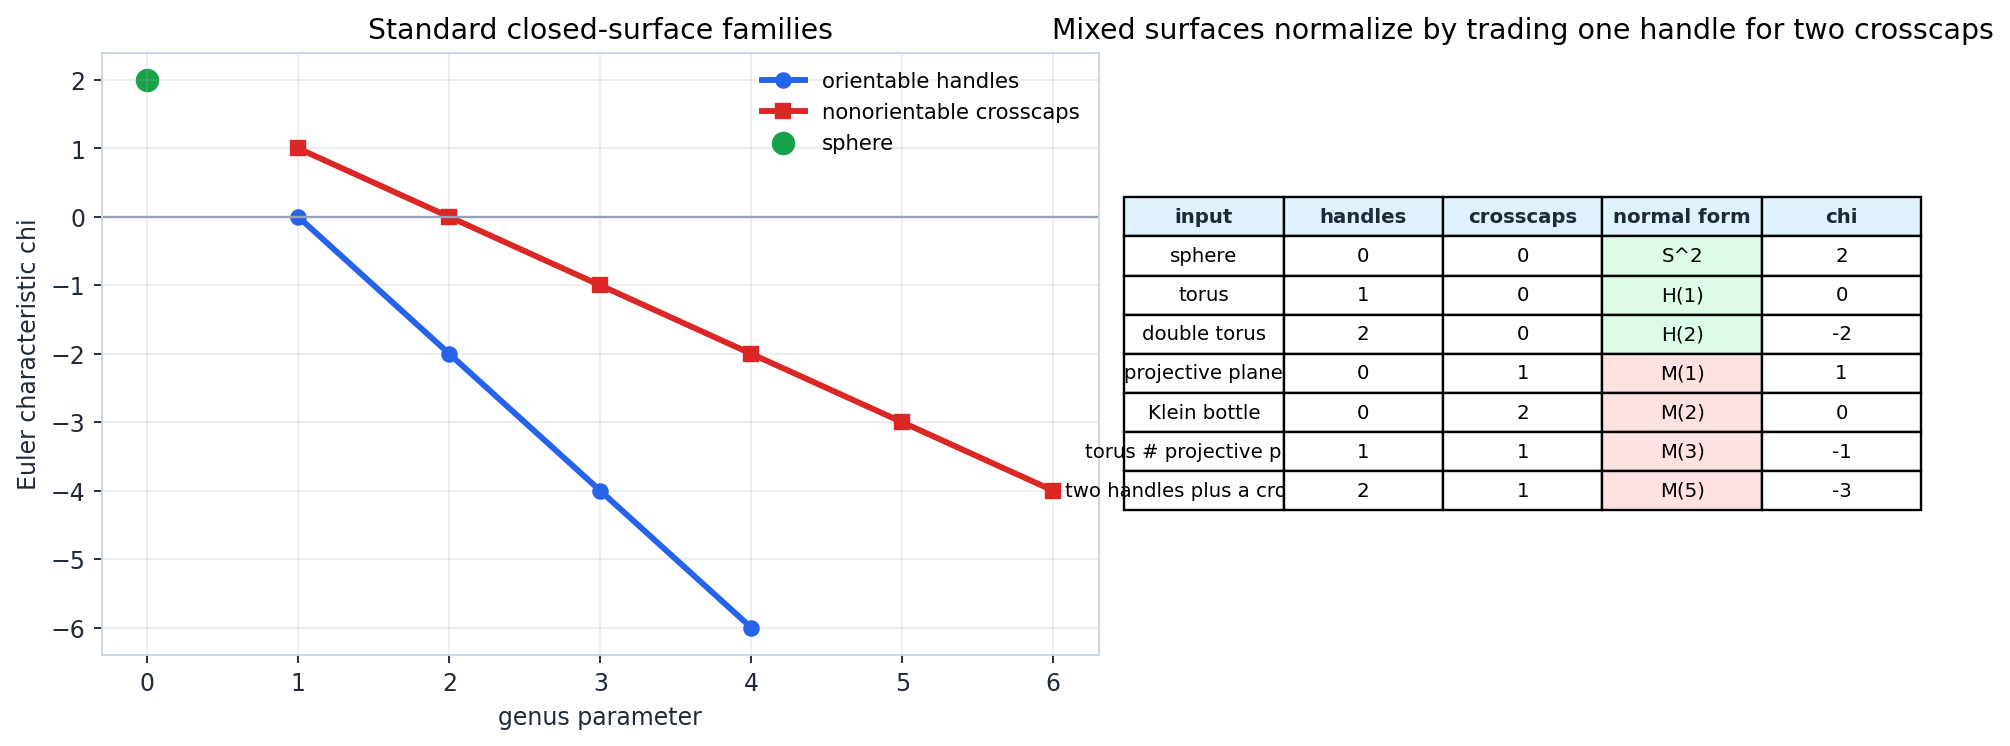

In [4]:
display_artifact(classification_fig, width=920)

## Surface Symbols As Edge Schemas

A surface symbol is a compact way to store a quotient polygon. Walk around the polygon and record each edge label; an inverse mark means the arrow on that side points against the walking direction. The quotient is the result of gluing equally labeled sides according to their arrows.

Two quick diagnostics are useful:

- every edge label must occur exactly twice,
- an orientable standard symbol has each label once with each direction.

The second test is deliberately local to these standard schemas. A general word can require reductions before it is in standard form.

In [5]:
def draw_arrow(ax, start, end, color=PALETTE["ink"], mutation_scale=14, lw=1.8):
    patch = FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=mutation_scale, linewidth=lw, color=color)
    ax.add_patch(patch)
    return patch


def regular_polygon(n: int, radius: float = 1.0, rotation: float = math.pi / 2) -> np.ndarray:
    angles = rotation - np.linspace(0, 2 * math.pi, n, endpoint=False)
    return np.column_stack([radius * np.cos(angles), radius * np.sin(angles)])


def draw_surface_schema(ax, title: str, word: list[tuple[str, int]], note: str) -> None:
    n = len(word)
    pts = regular_polygon(n, radius=1.0)
    ax.add_patch(Polygon(pts, closed=True, facecolor="#f8fafc", edgecolor=PALETTE["ink"], linewidth=2.0))
    color_for_label = {}
    colors = [PALETTE["blue"], PALETTE["teal"], PALETTE["red"], PALETTE["purple"], PALETTE["gold"], PALETTE["green"]]
    for label, _ in word:
        if label not in color_for_label:
            color_for_label[label] = colors[len(color_for_label) % len(colors)]
    for i, (label, sign) in enumerate(word):
        p = pts[i]
        q = pts[(i + 1) % n]
        start = 0.78 * p + 0.22 * q
        end = 0.22 * p + 0.78 * q
        if sign < 0:
            start, end = end, start
        color = color_for_label[label]
        draw_arrow(ax, start, end, color=color)
        mid = (p + q) / 2
        label_text = label if sign > 0 else f"{label}^-1"
        ax.text(1.12 * mid[0], 1.12 * mid[1], label_text, ha="center", va="center", color=color, weight="bold")
    ax.set_title(title, fontsize=11)
    ax.text(0, -1.35, note, ha="center", va="top", fontsize=8.6, color=PALETTE["ink"], wrap=True)
    ax.set_aspect("equal")
    ax.set_xlim(-1.45, 1.45)
    ax.set_ylim(-1.55, 1.35)
    ax.axis("off")


schema_specs = [
    {"name": "Torus H(1)", "symbol": [("a", 1), ("b", 1), ("a", -1), ("b", -1)], "note": "one handle; opposite directions for each pair"},
    {"name": "Double torus H(2)", "symbol": [("a", 1), ("b", 1), ("a", -1), ("b", -1), ("c", 1), ("d", 1), ("c", -1), ("d", -1)], "note": "two commutator blocks"},
    {"name": "Klein bottle M(2)", "symbol": [("a", 1), ("a", 1), ("b", 1), ("b", 1)], "note": "two crosscap labels in standard nonorientable form"},
    {"name": "Nonorientable M(3)", "symbol": [("a", 1), ("a", 1), ("b", 1), ("b", 1), ("c", 1), ("c", 1)], "note": "three crosscaps; no global orientation survives"},
]

fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.5))
for ax, spec in zip(axes.ravel(), schema_specs):
    draw_surface_schema(ax, spec["name"], spec["symbol"], spec["note"])
fig.suptitle("Surface symbols store the quotient, not a metric drawing", fontsize=14, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
schema_fig = save_matplotlib(fig, UNIT, "figures", "surface-symbol-edge-schemas.png", dpi=180)
plt.close(fig)
ARTIFACTS.append(schema_fig)

schema_checks = []
for spec in schema_specs:
    counts = Counter(label for label, sign in spec["symbol"])
    sign_counts = {label: Counter(sign for edge_label, sign in spec["symbol"] if edge_label == label) for label in counts}
    orientable_standard = all(sign_counts[label][1] == 1 and sign_counts[label][-1] == 1 for label in counts)
    schema_checks.append({
        "name": spec["name"],
        "edge_count": len(spec["symbol"]),
        "label_counts": dict(counts),
        "each_label_occurs_twice": all(count == 2 for count in counts.values()),
        "orientable_standard_schema": orientable_standard,
    })

schema_check_path = save_json({"schemas": schema_checks}, UNIT, "checks", "polygon-schema-checks.json")
ARTIFACTS.append(schema_check_path)
CHECK_PATHS.append(schema_check_path)

pd.DataFrame(schema_checks)

,name,edge_count,label_counts,each_label_occurs_twice,orientable_standard_schema
0,Torus H(1),4,"{'a': 2, 'b': 2}",True,True
1,Double torus H(2),8,"{'a': 2, 'b': 2, 'c': 2, 'd': 2}",True,True
2,Klein bottle M(2),4,"{'a': 2, 'b': 2}",True,False
3,Nonorientable M(3),6,"{'a': 2, 'b': 2, 'c': 2}",True,False


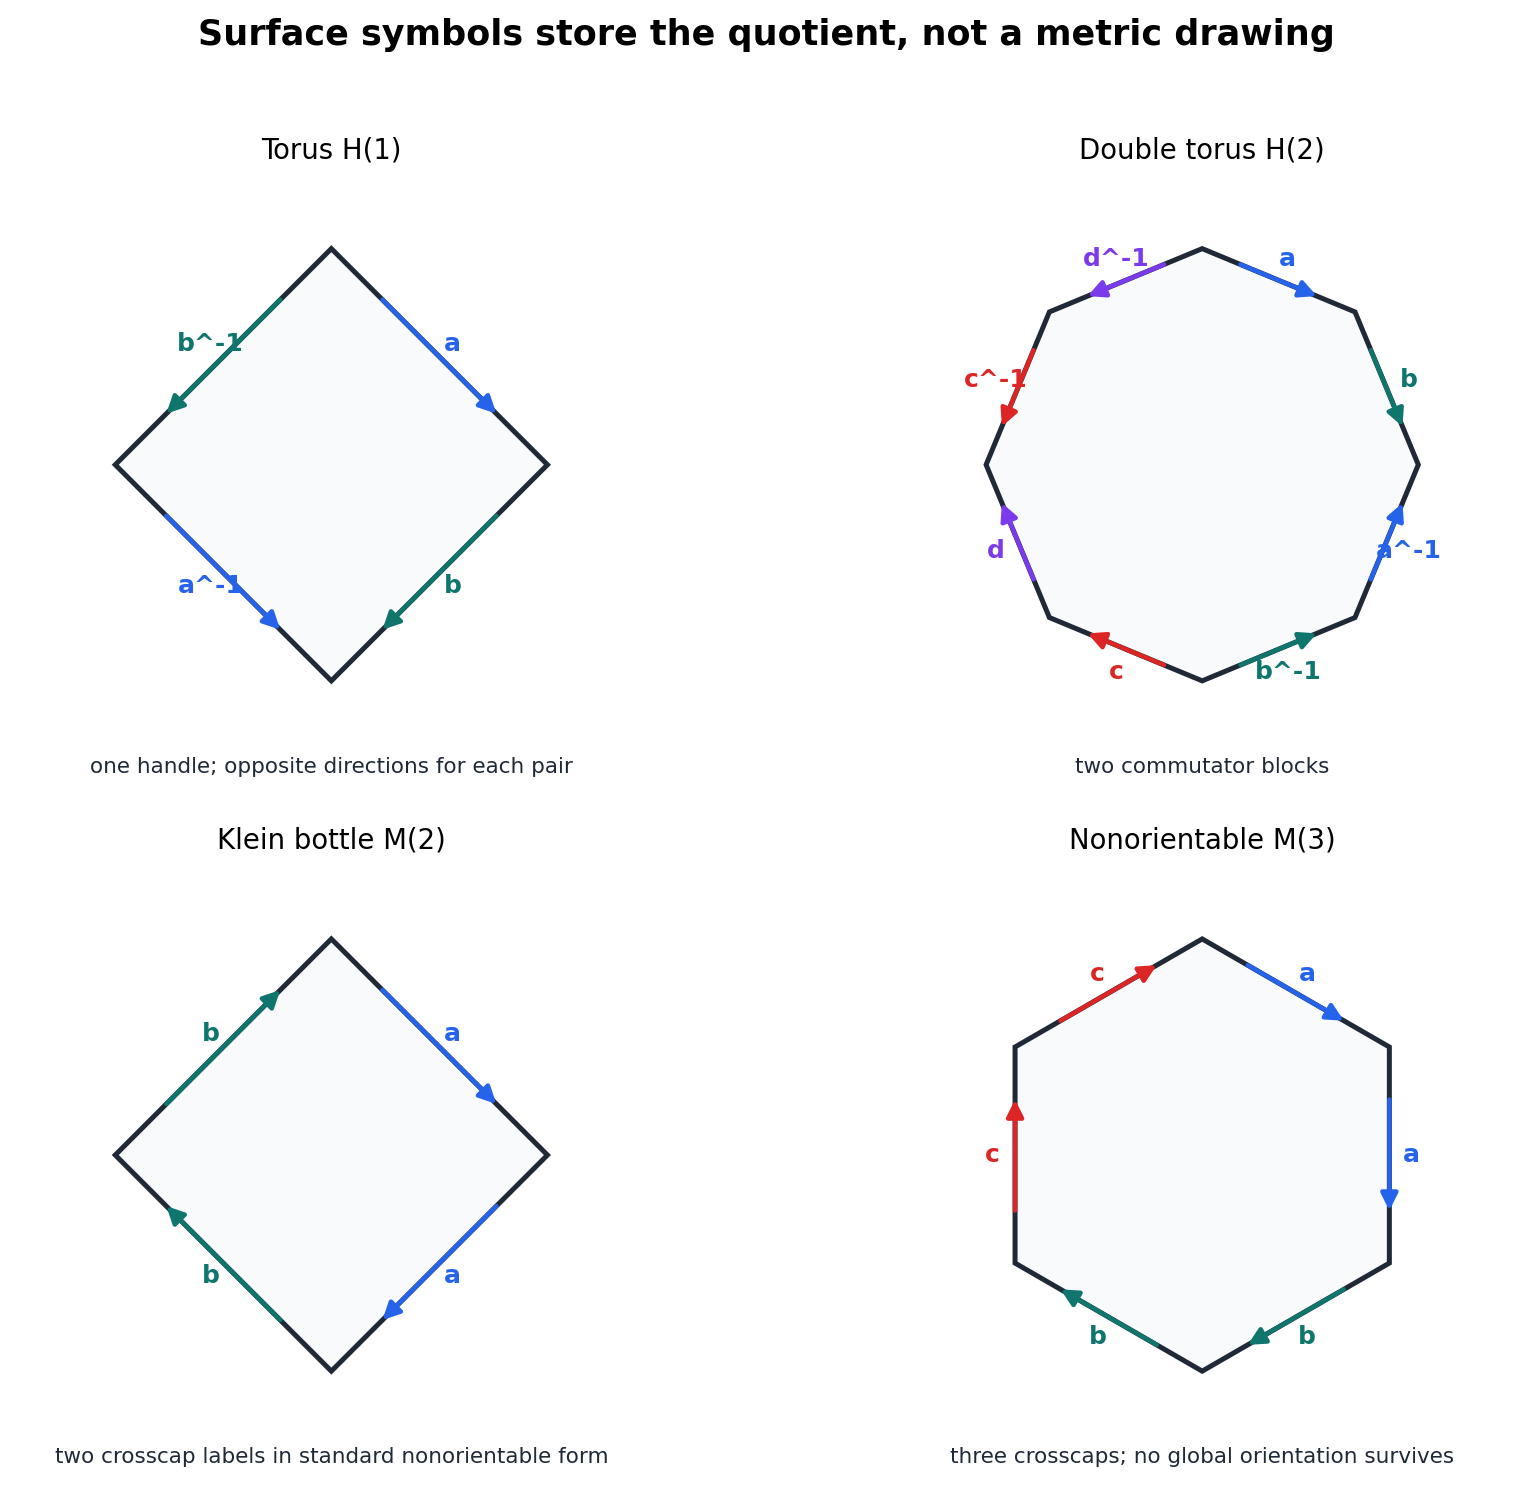

In [6]:
display_artifact(schema_fig, width=900)

## Orientability As A Constraint Test

A triangulated surface is orientable when every triangle can be oriented so that adjacent triangles induce opposite directions on their shared edge. That statement becomes a finite consistency problem:

1. give each triangle a provisional orientation,
2. each shared edge imposes a sign relation between the two incident triangles,
3. propagate the signs across the dual graph,
4. report success or the first contradiction.

The contradiction is the combinatorial shadow of carrying a small oriented disk around a one-sided loop and getting the opposite orientation back.

In [7]:
def canonical_vertex(i: int, j: int, nx_count: int, ny_count: int, *, twist: bool = False) -> tuple[int, int]:
    quotient_turns, y = divmod(j, ny_count)
    x_source = -i if twist and quotient_turns % 2 else i
    return (x_source % nx_count, y)


def grid_surface(nx_count: int, ny_count: int, *, twist: bool = False) -> tuple[list[tuple[int, int]], list[tuple[int, int, int]]]:
    vertices = sorted({canonical_vertex(i, j, nx_count, ny_count, twist=twist) for i in range(nx_count) for j in range(ny_count)})
    vertex_id = {vertex: index for index, vertex in enumerate(vertices)}
    triangles: list[tuple[int, int, int]] = []
    for i in range(nx_count):
        for j in range(ny_count):
            v00 = vertex_id[canonical_vertex(i, j, nx_count, ny_count, twist=twist)]
            v10 = vertex_id[canonical_vertex(i + 1, j, nx_count, ny_count, twist=twist)]
            v11 = vertex_id[canonical_vertex(i + 1, j + 1, nx_count, ny_count, twist=twist)]
            v01 = vertex_id[canonical_vertex(i, j + 1, nx_count, ny_count, twist=twist)]
            triangles.extend([(v00, v10, v11), (v00, v11, v01)])
    return vertices, triangles


def unique_edges(triangles: list[tuple[int, int, int]]) -> set[tuple[int, int]]:
    edges = set()
    for a, b, c in triangles:
        edges.update({tuple(sorted((a, b))), tuple(sorted((b, c))), tuple(sorted((c, a)))})
    return edges


def edge_incidence(triangles: list[tuple[int, int, int]]) -> dict[tuple[int, int], list[int]]:
    incidence: dict[tuple[int, int], list[int]] = defaultdict(list)
    for index, triangle in enumerate(triangles):
        for edge in [(triangle[0], triangle[1]), (triangle[1], triangle[2]), (triangle[2], triangle[0])]:
            incidence[tuple(sorted(edge))].append(index)
    return dict(incidence)


def directed_edge_sign(triangle: tuple[int, int, int], edge: tuple[int, int]) -> int:
    v0, v1, v2 = triangle
    boundary_edges = [(v1, v2), (v2, v0), (v0, v1)]
    a, b = edge
    for u, v in boundary_edges:
        if {u, v} == {a, b}:
            return 1 if (u, v) == (a, b) else -1
    raise ValueError(f"edge {edge} is not in triangle {triangle}")


def orientability_report(triangles: list[tuple[int, int, int]]) -> dict[str, object]:
    incidence = edge_incidence(triangles)
    bad_edges = {edge: faces for edge, faces in incidence.items() if len(faces) != 2}
    constraints: dict[int, list[tuple[int, int, tuple[int, int]]]] = defaultdict(list)
    for edge, faces in incidence.items():
        if len(faces) != 2:
            continue
        left, right = faces
        left_sign = directed_edge_sign(triangles[left], edge)
        right_sign = directed_edge_sign(triangles[right], edge)
        required = -(left_sign * right_sign)
        constraints[left].append((right, required, edge))
        constraints[right].append((left, required, edge))

    assignments: dict[int, int] = {}
    for start in range(len(triangles)):
        if start in assignments:
            continue
        assignments[start] = 1
        queue = deque([start])
        while queue:
            current = queue.popleft()
            for neighbor, required, edge in constraints[current]:
                proposed = assignments[current] * required
                if neighbor not in assignments:
                    assignments[neighbor] = proposed
                    queue.append(neighbor)
                elif assignments[neighbor] != proposed:
                    return {
                        "orientable": False,
                        "bad_edges": [[int(e[0]), int(e[1]), [int(f) for f in faces]] for e, faces in bad_edges.items()],
                        "contradiction": {
                            "triangle_a": int(current),
                            "triangle_b": int(neighbor),
                            "shared_edge": [int(edge[0]), int(edge[1])],
                            "existing_sign": int(assignments[neighbor]),
                            "required_sign": int(proposed),
                        },
                        "assigned_triangle_count": len(assignments),
                    }
    return {
        "orientable": True,
        "bad_edges": [[int(e[0]), int(e[1]), [int(f) for f in faces]] for e, faces in bad_edges.items()],
        "contradiction": None,
        "assigned_triangle_count": len(assignments),
    }


def cell_counts(vertices: list[object], triangles: list[tuple[int, int, int]]) -> dict[str, int]:
    edge_count = len(unique_edges(triangles))
    return {"V": len(vertices), "E": edge_count, "F": len(triangles), "chi": len(vertices) - edge_count + len(triangles)}


def make_model(name: str, vertices: list[object], triangles: list[tuple[int, int, int]], expected_surface: str) -> dict[str, object]:
    counts = cell_counts(vertices, triangles)
    orientability = orientability_report(triangles)
    incidence = edge_incidence(triangles)
    return {
        "name": name,
        "expected_surface": expected_surface,
        "vertices": vertices,
        "triangles": triangles,
        "counts": counts,
        "every_edge_has_two_faces": all(len(faces) == 2 for faces in incidence.values()),
        "orientability": orientability,
    }


sphere_vertices = [0, 1, 2, 3]
sphere_triangles = [(0, 1, 2), (0, 3, 1), (1, 3, 2), (2, 3, 0)]
torus_vertices, torus_triangles = grid_surface(3, 3, twist=False)
klein_vertices, klein_triangles = grid_surface(4, 4, twist=True)

SURFACE_MODELS = [
    make_model("tetrahedral sphere", sphere_vertices, sphere_triangles, "S^2"),
    make_model("3 by 3 periodic grid torus", torus_vertices, torus_triangles, "H(1)"),
    make_model("4 by 4 twisted grid Klein bottle", klein_vertices, klein_triangles, "M(2)"),
]

triangulation_records = []
for model in SURFACE_MODELS:
    triangulation_records.append({
        "model": model["name"],
        "expected_surface": model["expected_surface"],
        **model["counts"],
        "every_edge_has_two_faces": model["every_edge_has_two_faces"],
        "orientable": model["orientability"]["orientable"],
        "contradiction": model["orientability"]["contradiction"],
    })
triangulation_df = pd.DataFrame(triangulation_records)


def draw_grid_schema(ax, nx_count: int, ny_count: int, *, twist: bool, title: str) -> None:
    for x in range(nx_count + 1):
        ax.plot([x, x], [0, ny_count], color="#cbd5e1", linewidth=0.9)
    for y in range(ny_count + 1):
        ax.plot([0, nx_count], [y, y], color="#cbd5e1", linewidth=0.9)
    for x in range(nx_count):
        for y in range(ny_count):
            ax.plot([x, x + 1], [y, y + 1], color="#94a3b8", linewidth=0.8, alpha=0.8)
    draw_arrow(ax, (0, 0.45 * ny_count), (0, 0.75 * ny_count), color=PALETTE["blue"])
    draw_arrow(ax, (nx_count, 0.45 * ny_count), (nx_count, 0.75 * ny_count), color=PALETTE["blue"])
    if twist:
        draw_arrow(ax, (0.25 * nx_count, 0), (0.65 * nx_count, 0), color=PALETTE["red"])
        draw_arrow(ax, (0.65 * nx_count, ny_count), (0.25 * nx_count, ny_count), color=PALETTE["red"])
        ax.text(nx_count / 2, -0.45, "top and bottom glue with reversed sense", ha="center", fontsize=8.5, color=PALETTE["red"])
    else:
        draw_arrow(ax, (0.25 * nx_count, 0), (0.65 * nx_count, 0), color=PALETTE["green"])
        draw_arrow(ax, (0.25 * nx_count, ny_count), (0.65 * nx_count, ny_count), color=PALETTE["green"])
        ax.text(nx_count / 2, -0.45, "opposite sides glue with matching sense", ha="center", fontsize=8.5, color=PALETTE["green"])
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-0.35, nx_count + 0.35)
    ax.set_ylim(-0.7, ny_count + 0.35)
    ax.axis("off")


fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
G = nx.Graph([(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)])
pos = {0: (0, 0.9), 1: (-0.95, -0.35), 2: (0.95, -0.35), 3: (0, 0.05)}
nx.draw_networkx_edges(G, pos, ax=axes[0], edge_color="#94a3b8", width=1.6)
nx.draw_networkx_nodes(G, pos, ax=axes[0], node_color="#dbeafe", edgecolors=PALETTE["blue"], node_size=520)
nx.draw_networkx_labels(G, pos, ax=axes[0], font_size=9)
axes[0].set_title("Tetrahedral sphere\n4 triangles, compatible orientation")
axes[0].axis("off")

draw_grid_schema(axes[1], 3, 3, twist=False, title="Torus grid\norientation constraints are consistent")
draw_grid_schema(axes[2], 4, 4, twist=True, title="Klein bottle grid\na seam forces contradiction")
fig.suptitle("Orientability is a finite sign-consistency test on adjacent triangles", fontsize=14, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])
triangulation_fig = save_matplotlib(fig, UNIT, "figures", "triangulated-surface-orientability.png", dpi=180)
plt.close(fig)
ARTIFACTS.append(triangulation_fig)

triangulation_checks = {
    "models": triangulation_records,
    "expected_results": {
        "sphere_orientable": bool(triangulation_records[0]["orientable"]),
        "torus_orientable": bool(triangulation_records[1]["orientable"]),
        "klein_nonorientable": not bool(triangulation_records[2]["orientable"]),
        "all_edges_two_faces": all(record["every_edge_has_two_faces"] for record in triangulation_records),
    },
}
triangulation_check_path = save_json(triangulation_checks, UNIT, "checks", "triangulated-surface-examples.json")
ARTIFACTS.append(triangulation_check_path)
CHECK_PATHS.append(triangulation_check_path)

triangulation_df

,model,expected_surface,V,E,F,chi,every_edge_has_two_faces,orientable,contradiction
0,tetrahedral sphere,S^2,4,6,4,2,True,True,None
1,3 by 3 periodic grid torus,H(1),9,27,18,0,True,True,None
2,4 by 4 twisted grid Klein bottle,M(2),16,48,32,0,True,False,"{'triangle_a': 19, 'triangle_b': 20, 'shared_e..."


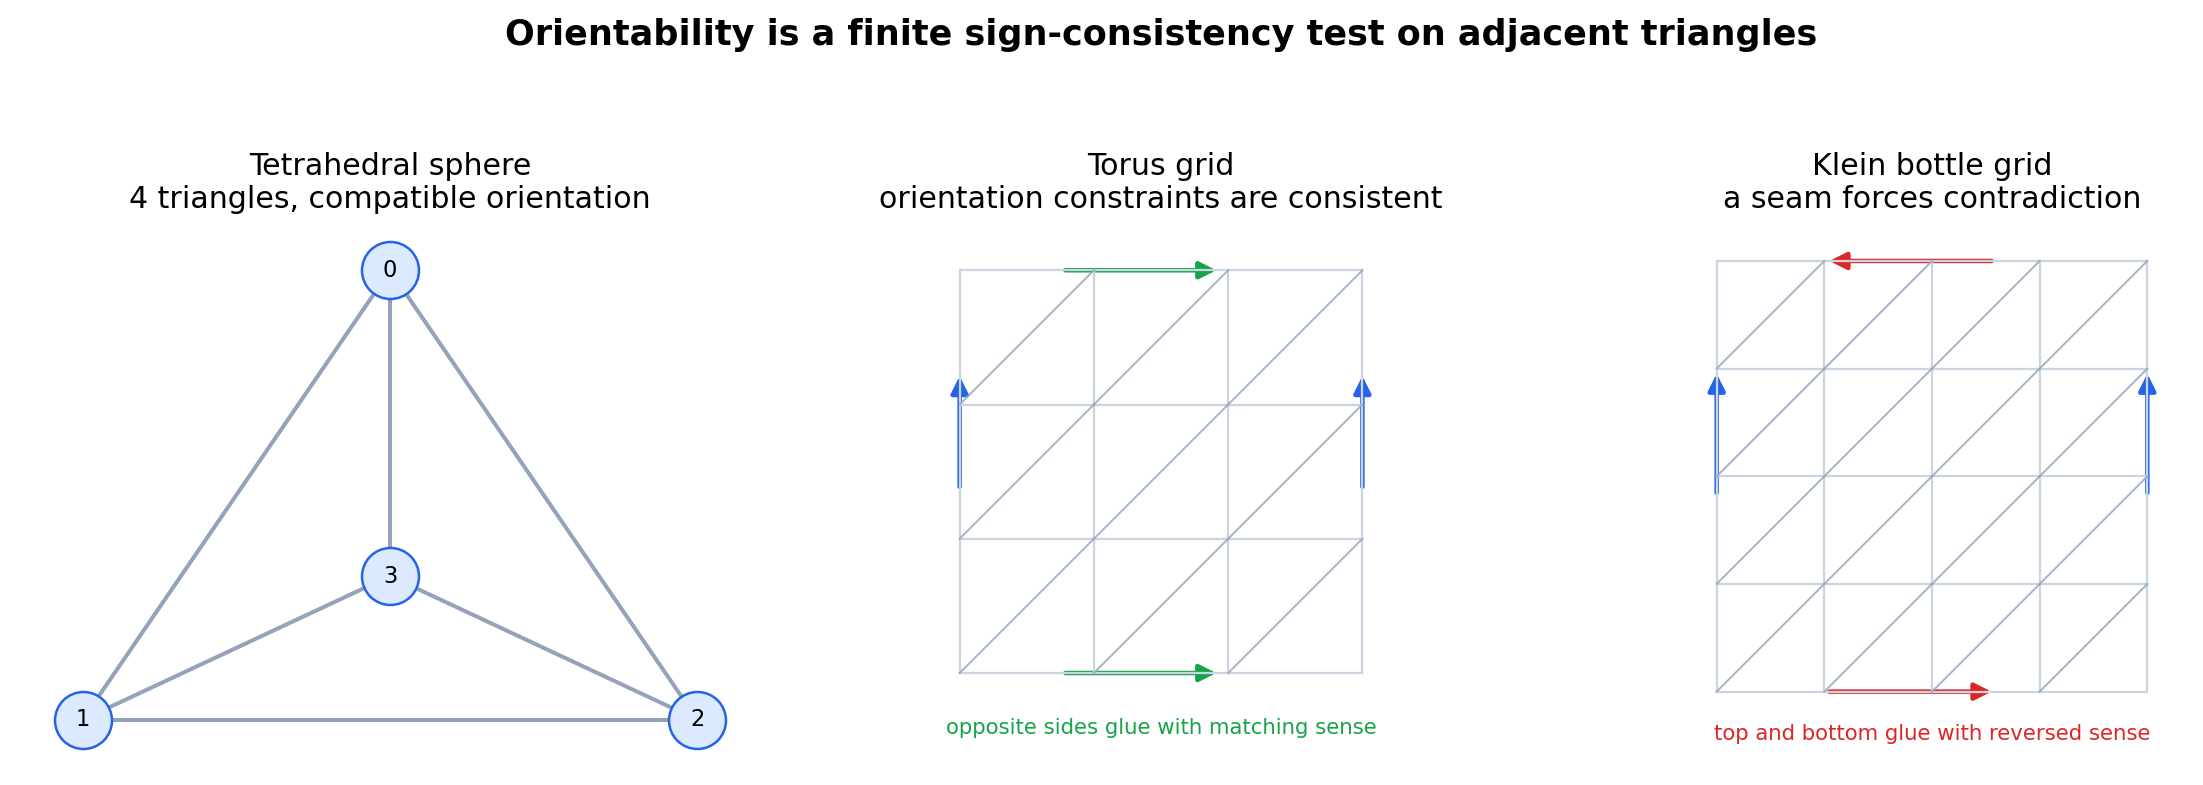

In [8]:
display_artifact(triangulation_fig, width=980)

## Euler Characteristic: Tree Plus Dual Graph

The chapter's Euler-characteristic argument uses a maximal tree `T` in the one-skeleton and a dual graph `Gamma` built from the triangles not crossed by `T`. The important ledger is

`chi(K) = chi(T) + chi(Gamma)`.

Since a maximal tree has `chi(T)=1` and every connected graph has `chi <= 1`, every combinatorial closed surface has `chi(K) <= 2`. Equality means the dual graph is also a tree, so the surface is a sphere in the proof strategy.

In [9]:
def primal_graph(triangles: list[tuple[int, int, int]]) -> nx.Graph:
    graph = nx.Graph()
    for edge in unique_edges(triangles):
        graph.add_edge(*edge)
    return graph


def dual_tree_ledger(model: dict[str, object]) -> dict[str, object]:
    triangles = model["triangles"]
    graph = primal_graph(triangles)
    tree = nx.minimum_spanning_tree(graph)
    tree_edges = {tuple(sorted(edge)) for edge in tree.edges()}
    incidence = edge_incidence(triangles)
    gamma = nx.MultiGraph()
    gamma.add_nodes_from(range(len(triangles)))
    for edge, faces in incidence.items():
        if tuple(sorted(edge)) not in tree_edges:
            if len(faces) == 2:
                gamma.add_edge(faces[0], faces[1], primal_edge=edge)
    counts = model["counts"]
    tree_chi = tree.number_of_nodes() - tree.number_of_edges()
    gamma_chi = gamma.number_of_nodes() - gamma.number_of_edges()
    return {
        "model": model["name"],
        "expected_surface": model["expected_surface"],
        "chi_K": counts["chi"],
        "tree_vertices": tree.number_of_nodes(),
        "tree_edges": tree.number_of_edges(),
        "chi_T": tree_chi,
        "gamma_vertices": gamma.number_of_nodes(),
        "gamma_edges": gamma.number_of_edges(),
        "chi_Gamma": gamma_chi,
        "identity_holds": counts["chi"] == tree_chi + gamma_chi,
        "gamma_is_tree": nx.is_tree(nx.Graph(gamma)) if gamma.number_of_nodes() else False,
    }


dual_records = [dual_tree_ledger(model) for model in SURFACE_MODELS]
dual_df = pd.DataFrame(dual_records)

proof_graph = nx.DiGraph()
proof_edges = [
    ("closed triangulated surface K", "maximal tree T"),
    ("closed triangulated surface K", "dual graph Gamma"),
    ("maximal tree T", "chi(T)=1"),
    ("dual graph Gamma", "graph lemma: chi(Gamma)<=1"),
    ("chi(T)=1", "chi(K)=chi(T)+chi(Gamma)"),
    ("graph lemma: chi(Gamma)<=1", "chi(K)<=2"),
    ("chi(K)=chi(T)+chi(Gamma)", "chi(K)<=2"),
    ("chi(K)=2", "Gamma is a tree"),
    ("Gamma is a tree", "K is a sphere"),
    ("nonseparating curve exists", "surgery can raise chi"),
]
proof_graph.add_edges_from(proof_edges)
manual_pos = {
    "closed triangulated surface K": (0.0, 1.0),
    "maximal tree T": (-1.8, 0.35),
    "dual graph Gamma": (1.8, 0.35),
    "chi(T)=1": (-1.8, -0.35),
    "graph lemma: chi(Gamma)<=1": (1.8, -0.35),
    "chi(K)=chi(T)+chi(Gamma)": (0.0, -0.95),
    "chi(K)<=2": (0.0, -1.65),
    "chi(K)=2": (-1.15, -2.35),
    "Gamma is a tree": (0.35, -2.35),
    "K is a sphere": (1.65, -2.35),
    "nonseparating curve exists": (0.0, -2.95),
    "surgery can raise chi": (0.0, -3.55),
}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.2), gridspec_kw={"width_ratios": [1.35, 1]})
ax = axes[0]
nx.draw_networkx_edges(proof_graph, manual_pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=12, edge_color="#94a3b8", width=1.4)
node_colors = ["#dbeafe" if "chi" not in node else "#fef3c7" for node in proof_graph.nodes]
nx.draw_networkx_nodes(proof_graph, manual_pos, ax=ax, node_color=node_colors, edgecolors="#475569", node_size=1700)
nx.draw_networkx_labels(proof_graph, manual_pos, ax=ax, font_size=8.2)
ax.set_title("Proof scaffold: why chi(K) cannot exceed 2")
ax.axis("off")

ax = axes[1]
x = np.arange(len(dual_df))
ax.bar(x - 0.18, dual_df["chi_K"], width=0.36, color=PALETTE["blue"], label="chi(K)")
ax.bar(x + 0.18, dual_df["chi_Gamma"], width=0.36, color=PALETTE["gold"], label="chi(Gamma)")
ax.axhline(1, color="#94a3b8", linestyle="--", linewidth=1, label="graph upper bound")
ax.set_xticks(x, dual_df["expected_surface"], rotation=0)
ax.set_ylabel("Euler characteristic")
ax.set_title("With chi(T)=1, the dual graph accounts for the rest")
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="y", alpha=0.22)
for i, record in enumerate(dual_records):
    ax.text(i, min(record["chi_K"], record["chi_Gamma"]) - 0.35, f"identity: {record['identity_holds']}", ha="center", fontsize=8)

fig.tight_layout()
dual_fig = save_matplotlib(fig, UNIT, "figures", "euler-dual-tree-proof-scaffold.png", dpi=180)
plt.close(fig)
ARTIFACTS.append(dual_fig)

dual_check_path = save_json({"dual_tree_ledgers": dual_records}, UNIT, "checks", "dual-tree-euler-checks.json")
ARTIFACTS.append(dual_check_path)
CHECK_PATHS.append(dual_check_path)

dual_df

,model,expected_surface,chi_K,tree_vertices,tree_edges,chi_T,gamma_vertices,gamma_edges,chi_Gamma,identity_holds,gamma_is_tree
0,tetrahedral sphere,S^2,2,4,3,1,4,3,1,True,True
1,3 by 3 periodic grid torus,H(1),0,9,8,1,18,19,-1,True,False
2,4 by 4 twisted grid Klein bottle,M(2),0,16,15,1,32,33,-1,True,False


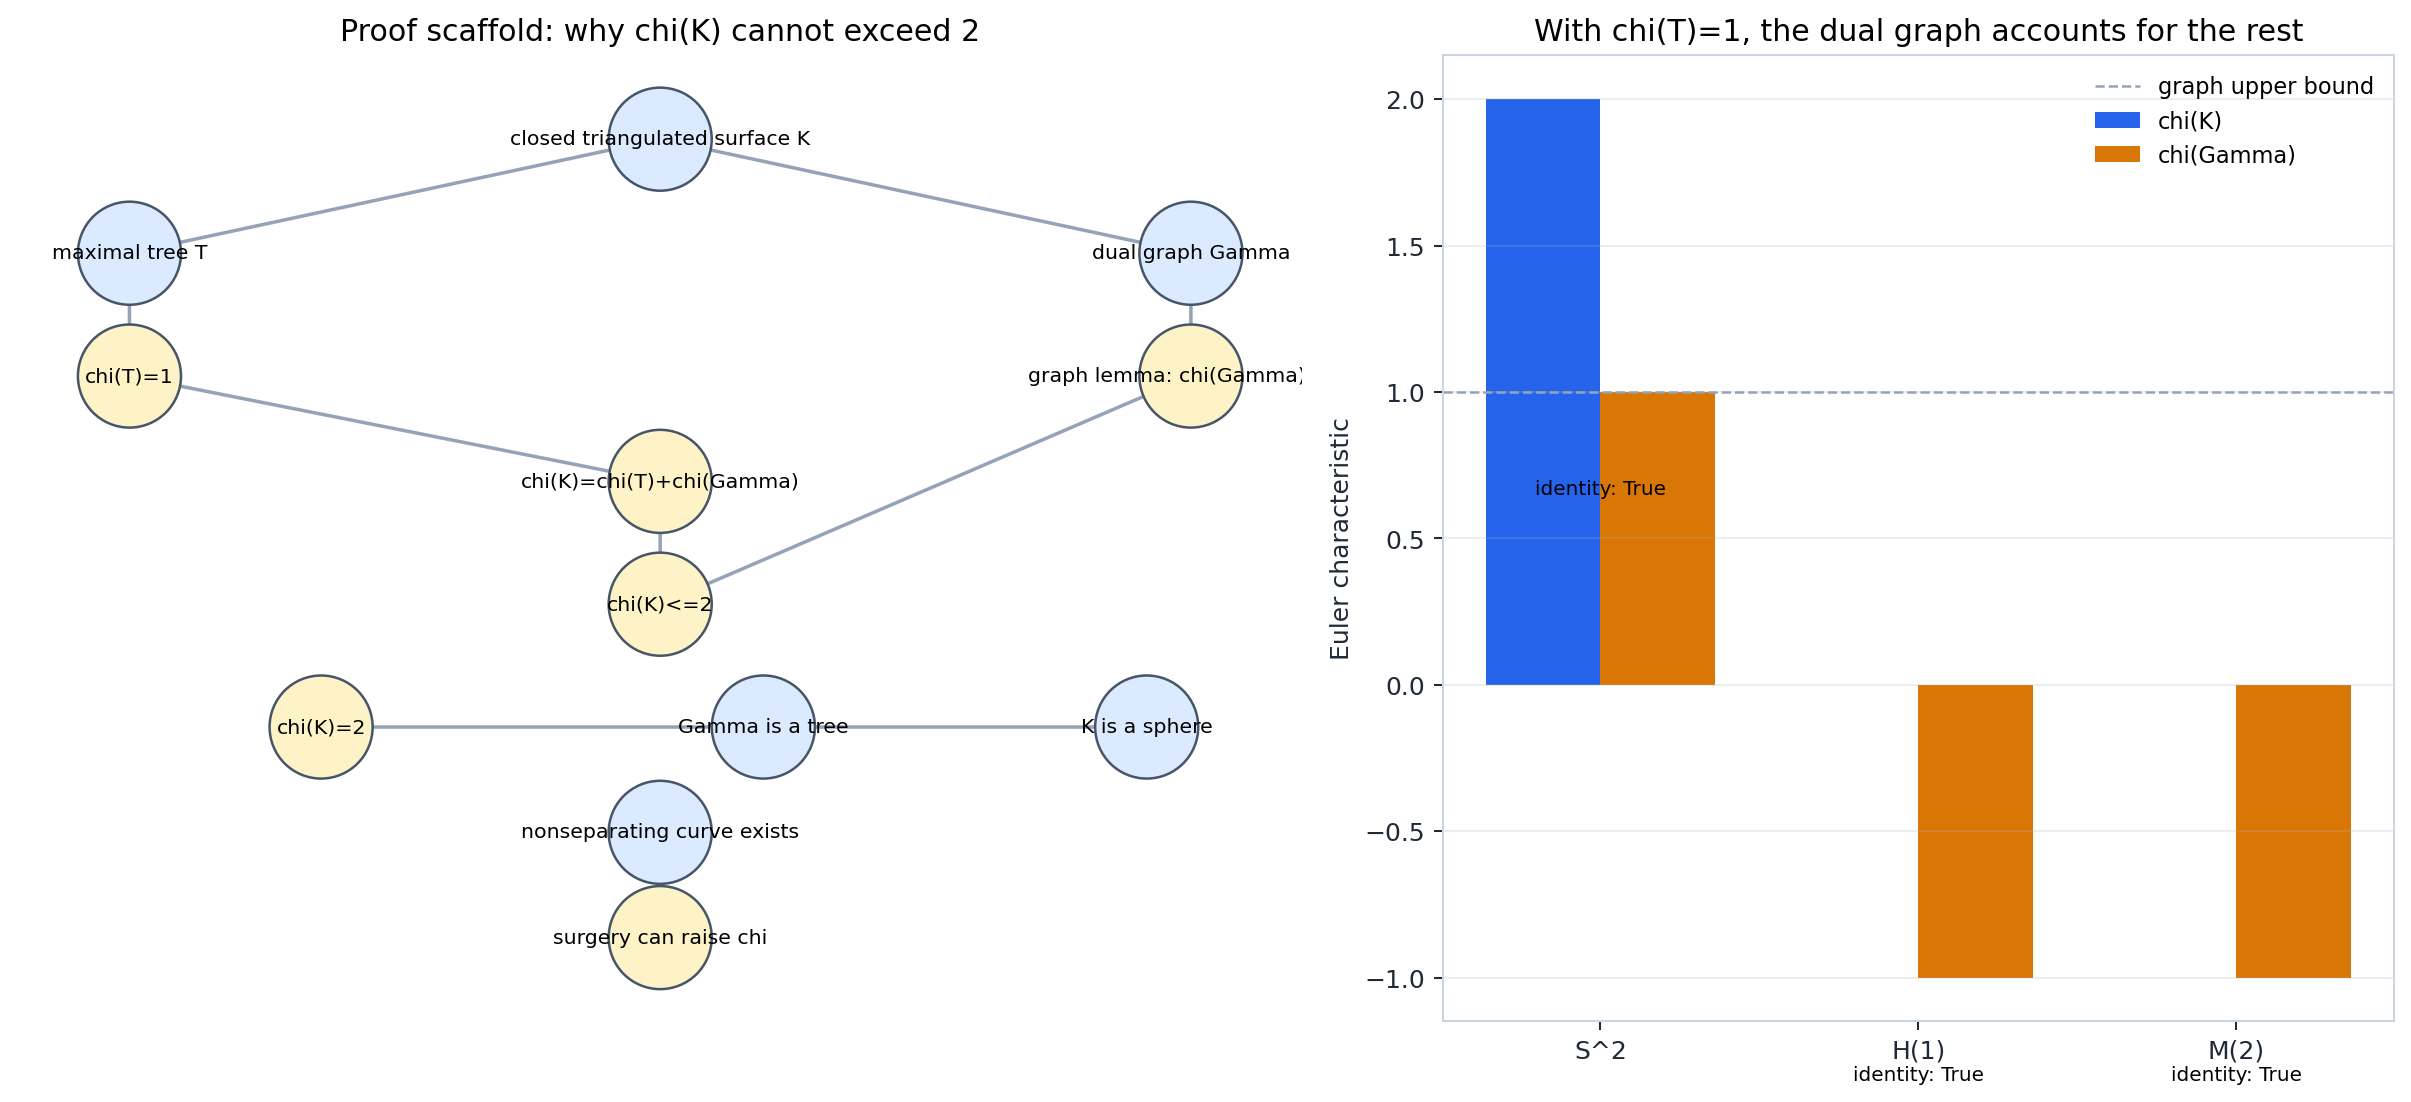

In [10]:
display_artifact(dual_fig, width=980)

## Surgery And Connected Sum Ledger

Surgery cuts out a thickened nonseparating simple closed curve and fills the boundary circles with disks. The Euler characteristic changes because the thickened curve has `chi = 0`, while the caps contribute disk Euler characteristic.

- If the thickening is a cylinder, surgery caps two boundary circles and raises `chi` by `2`.
- If the thickening is a Mobius band, surgery caps one boundary circle and raises `chi` by `1`.

Connected sum is the reverse style of bookkeeping: remove one disk from each surface and glue along the new boundary circle. This subtracts `2` from the sum of Euler characteristics:

`chi(S # T) = chi(S) + chi(T) - 2`.

In [11]:
def connected_sum(surface_a: dict[str, object], surface_b: dict[str, object]) -> dict[str, object]:
    chi = int(surface_a["chi"]) + int(surface_b["chi"]) - 2
    handles = 0
    crosscaps = 0
    if surface_a["orientable"]:
        handles += int(surface_a["genus"])
    else:
        crosscaps += int(surface_a["genus"])
    if surface_b["orientable"]:
        handles += int(surface_b["genus"])
    else:
        crosscaps += int(surface_b["genus"])
    normal = normalize_surface(handles, crosscaps)
    return {"input_chi_formula": chi, **normal}


def surgery_path_from_orientable(p: int) -> list[dict[str, object]]:
    path = []
    for step in range(p + 1):
        remaining = p - step
        normal = normalize_surface(remaining, 0)
        path.append({"step": step, "operation": "two-sided surgery" if step else "start", **normal})
    return path


def surgery_path_from_nonorientable(q: int) -> list[dict[str, object]]:
    path = []
    for step in range(q + 1):
        remaining = q - step
        normal = normalize_surface(0, remaining) if remaining else normalize_surface(0, 0)
        path.append({"step": step, "operation": "one-sided surgery" if step else "start", **normal})
    return path


h3_path = surgery_path_from_orientable(3)
m5_path = surgery_path_from_nonorientable(5)
mixed_path = surgery_path_from_nonorientable(2 * 2 + 1)

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8), gridspec_kw={"width_ratios": [1.2, 1]})
ax = axes[0]
for path, label, color, marker in [
    (h3_path, "H(3): three cylinder surgeries", PALETTE["blue"], "o"),
    (m5_path, "M(5): five one-sided surgeries", PALETTE["red"], "s"),
    (mixed_path, "H(2) plus one crosscap = M(5)", PALETTE["purple"], "^"),
]:
    ax.plot([row["step"] for row in path], [row["chi"] for row in path], marker=marker, linewidth=2.4, color=color, label=label)
ax.axhline(2, color="#94a3b8", linestyle="--", linewidth=1.2)
ax.text(0.05, 2.15, "sphere target chi=2", fontsize=8.5, color=PALETTE["ink"])
ax.set_xlabel("surgery step")
ax.set_ylabel("Euler characteristic chi")
ax.set_title("Surgery raises chi until a sphere remains")
ax.grid(alpha=0.22)
ax.legend(frameon=False, fontsize=8.4)

ax = axes[1]
operations = pd.DataFrame([
    {"move": "two-sided surgery", "thickening": "cylinder", "caps_added": 2, "delta_chi": 2},
    {"move": "one-sided surgery", "thickening": "Mobius band", "caps_added": 1, "delta_chi": 1},
    {"move": "connected sum", "thickening": "reverse disk gluing", "caps_added": -2, "delta_chi": -2},
    {"move": "add handle", "thickening": "reverse two-sided surgery", "caps_added": -2, "delta_chi": -2},
    {"move": "add crosscap", "thickening": "reverse one-sided surgery", "caps_added": -1, "delta_chi": -1},
])
ax.axis("off")
table = ax.table(
    cellText=operations.astype(str).values.tolist(),
    colLabels=operations.columns.tolist(),
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8.4)
table.scale(1, 1.35)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor("#e0f2fe")
        cell.set_text_props(weight="bold")
    elif c == 3 and cell.get_text().get_text().startswith("-"):
        cell.set_facecolor("#fee2e2")
    elif c == 3:
        cell.set_facecolor("#dcfce7")
ax.set_title("Local move ledger")

fig.tight_layout()
surgery_fig = save_matplotlib(fig, UNIT, "figures", "surgery-connected-sum-ledger.png", dpi=180)
plt.close(fig)
ARTIFACTS.append(surgery_fig)

plotly_fig = go.Figure()
for path, label, color in [
    (h3_path, "H(3) to sphere", PALETTE["blue"]),
    (m5_path, "M(5) to sphere", PALETTE["red"]),
    (mixed_path, "H(2)+crosscap, normalized as M(5)", PALETTE["purple"]),
]:
    plotly_fig.add_trace(go.Scatter(
        x=[row["step"] for row in path],
        y=[row["chi"] for row in path],
        mode="lines+markers+text",
        text=[row["normal_form"] for row in path],
        textposition="top center",
        name=label,
        line={"color": color, "width": 3},
    ))
plotly_fig.update_layout(
    title="Surgery trajectories in the classification ledger",
    xaxis_title="surgery step",
    yaxis_title="Euler characteristic chi",
    width=850,
    height=520,
    template="plotly_white",
)
surgery_html = save_plotly_html(plotly_fig, UNIT, "html", "surgery-euler-lab.html", include_plotlyjs="cdn")
ARTIFACTS.append(surgery_html)

sum_examples = [
    (normalize_surface(1, 0), normalize_surface(1, 0), "torus # torus"),
    (normalize_surface(0, 1), normalize_surface(0, 1), "projective plane # projective plane"),
    (normalize_surface(1, 0), normalize_surface(0, 1), "torus # projective plane"),
]
connected_sum_records = []
for left, right, label in sum_examples:
    result = connected_sum(left, right)
    connected_sum_records.append({
        "operation": label,
        "left": left["normal_form"],
        "right": right["normal_form"],
        "result": result["normal_form"],
        "chi_from_formula": result["input_chi_formula"],
        "chi_from_normal_form": result["chi"],
        "chi_agrees": result["input_chi_formula"] == result["chi"],
    })
connected_sum_df = pd.DataFrame(connected_sum_records)
connected_sum_csv = TABLE_DIR / "connected-sum-lab.csv"
connected_sum_df.to_csv(connected_sum_csv, index=False)
ARTIFACTS.append(connected_sum_csv)

surgery_checks = {
    "paths": {
        "H3": h3_path,
        "M5": m5_path,
        "mixed_H2_plus_crosscap_as_M5": mixed_path,
    },
    "operation_deltas": json.loads(operations.to_json(orient="records")),
    "connected_sum_examples": connected_sum_records,
    "identity_checks": {
        "two_sided_surgery_delta": h3_path[1]["chi"] - h3_path[0]["chi"] == 2,
        "one_sided_surgery_delta": m5_path[1]["chi"] - m5_path[0]["chi"] == 1,
        "torus_sum_torus_is_H2": connected_sum_records[0]["result"] == "H(2)",
        "projective_sum_projective_is_M2": connected_sum_records[1]["result"] == "M(2)",
        "torus_sum_projective_is_M3": connected_sum_records[2]["result"] == "M(3)",
    },
}
surgery_check_path = save_json(surgery_checks, UNIT, "checks", "surgery-ledger-checks.json")
ARTIFACTS.append(surgery_check_path)
CHECK_PATHS.append(surgery_check_path)

connected_sum_df

,operation,left,right,result,chi_from_formula,chi_from_normal_form,chi_agrees
0,torus # torus,H(1),H(1),H(2),-2,-2,True
1,projective plane # projective plane,M(1),M(1),M(2),0,0,True
2,torus # projective plane,H(1),M(1),M(3),-1,-1,True


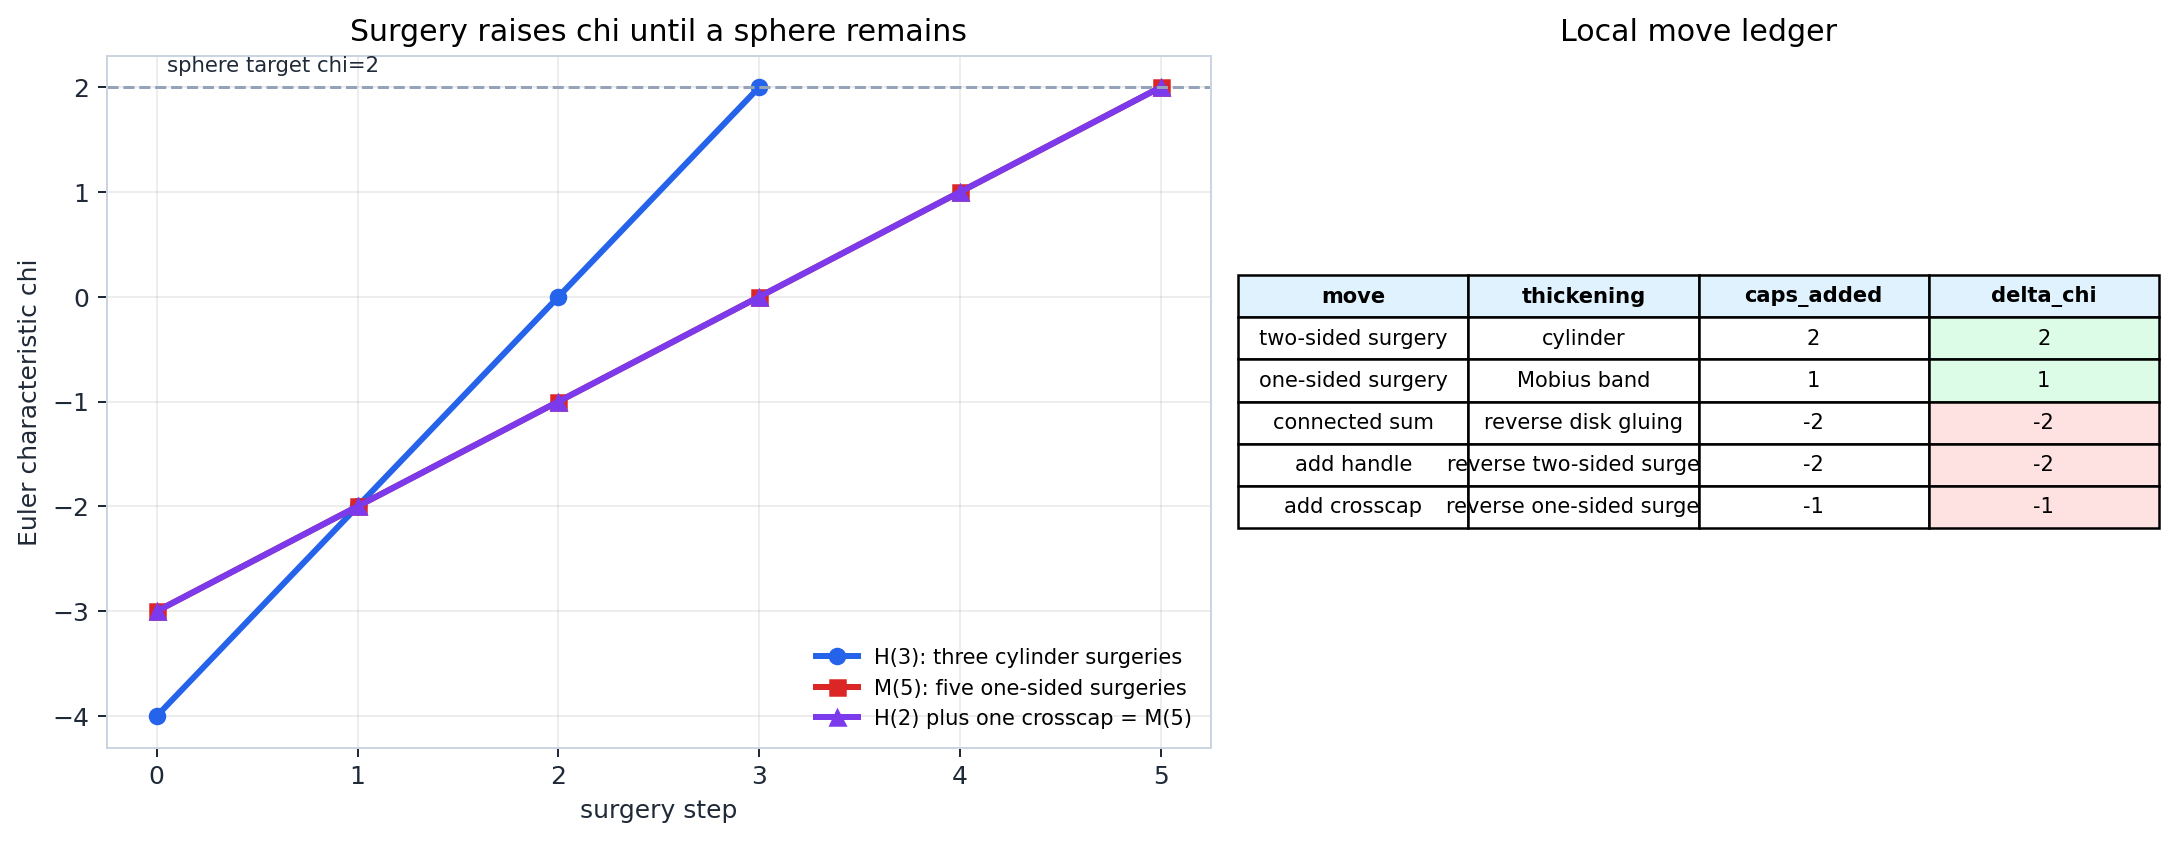

In [12]:
display_artifact(surgery_fig, width=960)
display_artifact(surgery_html, width="100%", height=540)

## Applied Lab: Normalize A Surface Description

Change `lab_inputs` and rerun the next cell. The rule is intentionally small:

- no crosscaps means the surface is orientable, so the handle count is the genus;
- any crosscap makes the surface nonorientable, and each handle contributes two crosscaps to the normal form;
- the Euler characteristic follows from the normal form.

This lab is a compact version of the classification theorem's constructive half: after surgery reduces a surface to the sphere, reversing the surgeries produces handles and crosscaps, then the ledger normalizes the result.

In [13]:
lab_inputs = [
    {"description": "sphere", "handles": 0, "crosscaps": 0},
    {"description": "one handle", "handles": 1, "crosscaps": 0},
    {"description": "two handles", "handles": 2, "crosscaps": 0},
    {"description": "one crosscap", "handles": 0, "crosscaps": 1},
    {"description": "two crosscaps", "handles": 0, "crosscaps": 2},
    {"description": "one handle plus one crosscap", "handles": 1, "crosscaps": 1},
    {"description": "three handles plus two crosscaps", "handles": 3, "crosscaps": 2},
]

lab_records = []
for row in lab_inputs:
    normal = normalize_surface(row["handles"], row["crosscaps"])
    lab_records.append({**row, **normal})
lab_df = pd.DataFrame(lab_records)
lab_csv = TABLE_DIR / "surface-normal-form-lab.csv"
lab_df.to_csv(lab_csv, index=False)
ARTIFACTS.append(lab_csv)

lab_check_path = save_json({"lab_records": json.loads(lab_df.to_json(orient="records"))}, UNIT, "checks", "surface-normal-form-lab.json")
ARTIFACTS.append(lab_check_path)
CHECK_PATHS.append(lab_check_path)

lab_df

,description,handles,crosscaps,normal_form,orientable,genus,chi
0,sphere,0,0,S^2,True,0,2
1,one handle,1,0,H(1),True,1,0
2,two handles,2,0,H(2),True,2,-2
3,one crosscap,0,1,M(1),False,1,1
4,two crosscaps,0,2,M(2),False,2,0
5,one handle plus one crosscap,1,1,M(3),False,3,-1
6,three handles plus two crosscaps,3,2,M(8),False,8,-6


## Final Sanity Checks

The final cell verifies the mathematical identities used above and the artifact contract for this chapter. These checks are part of the lesson: they connect the visible diagrams to reproducible claims.

In [14]:
expected_artifacts = [
    storyboard_path,
    classification_fig,
    classification_csv,
    classification_check_path,
    schema_fig,
    schema_check_path,
    triangulation_fig,
    triangulation_check_path,
    dual_fig,
    dual_check_path,
    surgery_fig,
    surgery_html,
    connected_sum_csv,
    surgery_check_path,
    lab_csv,
    lab_check_path,
]

for artifact in expected_artifacts:
    suffix = artifact.suffix.lower()
    min_bytes = 1024 if suffix in {".png", ".html"} else 32
    assert_artifact(artifact, min_bytes=min_bytes)

assert chi_orientable(0) == 2
assert chi_orientable(1) == 0
assert chi_orientable(2) == -2
assert chi_nonorientable(1) == 1
assert chi_nonorientable(2) == 0
assert normalize_surface(2, 1)["normal_form"] == "M(5)"
assert normalize_surface(0, 0)["normal_form"] == "S^2"
assert connected_sum(normalize_surface(1, 0), normalize_surface(1, 0))["normal_form"] == "H(2)"
assert connected_sum(normalize_surface(1, 0), normalize_surface(0, 1))["normal_form"] == "M(3)"

model_by_surface = {record["expected_surface"]: record for record in triangulation_records}
assert model_by_surface["S^2"]["chi"] == 2 and model_by_surface["S^2"]["orientable"] is True
assert model_by_surface["H(1)"]["chi"] == 0 and model_by_surface["H(1)"]["orientable"] is True
assert model_by_surface["M(2)"]["chi"] == 0 and model_by_surface["M(2)"]["orientable"] is False
assert all(record["every_edge_has_two_faces"] for record in triangulation_records)
assert all(record["identity_holds"] for record in dual_records)
assert dual_records[0]["gamma_is_tree"] is True
assert dual_records[1]["gamma_is_tree"] is False
assert surgery_checks["identity_checks"]["two_sided_surgery_delta"]
assert surgery_checks["identity_checks"]["one_sided_surgery_delta"]
assert all(record["chi_agrees"] for record in connected_sum_records)

final_sanity = {
    "artifact_count": len(expected_artifacts),
    "check_files": [str(path.relative_to(BOOK_ROOT)) for path in CHECK_PATHS],
    "core_identities": {
        "chi_H_p": "2 - 2p",
        "chi_M_q": "2 - q",
        "connected_sum_chi": "chi(S#T) = chi(S) + chi(T) - 2",
        "mixed_normal_form": "handles=m, crosscaps=n>0 -> M(2m+n)",
    },
    "triangulation_results": triangulation_records,
    "dual_tree_identity_holds_for_all_models": all(record["identity_holds"] for record in dual_records),
    "all_artifacts_nonempty": True,
}
final_sanity_path = save_json(final_sanity, UNIT, "checks", "final-sanity.json")
assert_artifact(final_sanity_path, min_bytes=64)
ARTIFACTS.append(final_sanity_path)
CHECK_PATHS.append(final_sanity_path)

final_sanity

{'artifact_count': 16,
 'check_files': ['artifacts\\chapter-07\\checks\\visual-storyboard.json',
  'artifacts\\chapter-07\\checks\\classification-ledger-checks.json',
  'artifacts\\chapter-07\\checks\\polygon-schema-checks.json',
  'artifacts\\chapter-07\\checks\\triangulated-surface-examples.json',
  'artifacts\\chapter-07\\checks\\dual-tree-euler-checks.json',
  'artifacts\\chapter-07\\checks\\surgery-ledger-checks.json',
  'artifacts\\chapter-07\\checks\\surface-normal-form-lab.json'],
 'core_identities': {'chi_H_p': '2 - 2p',
  'chi_M_q': '2 - q',
  'connected_sum_chi': 'chi(S#T) = chi(S) + chi(T) - 2',
  'mixed_normal_form': 'handles=m, crosscaps=n>0 -> M(2m+n)'},
 'triangulation_results': [{'model': 'tetrahedral sphere',
   'expected_surface': 'S^2',
   'V': 4,
   'E': 6,
   'F': 4,
   'chi': 2,
   'every_edge_has_two_faces': True,
   'orientable': True,
   'contradiction': None},
  {'model': '3 by 3 periodic grid torus',
   'expected_surface': 'H(1)',
   'V': 9,
   'E': 27,
   '

## Takeaways

Closed-surface classification becomes usable when each topological move has a small ledger. Surface symbols store quotient data. Orientability is a global consistency condition on local triangle orientations. Euler characteristic is stable enough to guide the proof, but it must be paired with orientability to distinguish the torus from the Klein bottle. Surgery raises `chi` until the surface becomes a sphere; reversing those surgeries reconstructs the standard handle or crosscap form.

The artifacts under `artifacts/chapter-07/` are part of the chapter: each figure has a nearby invariant check, and the final sanity cell verifies the identities used by the notebook.

A useful way to read the chapter is to keep three ledgers side by side: the edge word says how to assemble the surface, the orientation test says whether a coherent local choice survives globally, and the surgery ledger says how far the surface is from the sphere.